# 0. Imports

In [8]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 1. Configuration

In [9]:
ROOT = Path('..').resolve()
FIGURES = ROOT / 'data' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

CLOUDS = {
    'aws':   ('eks', sorted((ROOT / 'metrics' / 'aws').glob('*/'))[-1]),
    'azure': ('aks', sorted((ROOT / 'metrics' / 'azure').glob('*/'))[-1]),
    'gcp':   ('gke', sorted((ROOT / 'metrics' / 'gcp').glob('*/'))[-1]),
}

PERF_METRICS = ['testDuration', 'ttfb', 'domInteractive', 'domContentLoaded',
                'loadComplete', 'fcp', 'lcp', 'cls', 'tbt', 'inp']

NAV_METRICS = ['dnsLookup', 'tcpConnect', 'tlsHandshake', 'serverProcessing', 'contentDownload']

CLOUD_ORDER  = ['aws', 'azure', 'gcp']
PALETTE      = {'aws': '#66c2a5', 'azure': '#fc8d62', 'gcp': '#8da0cb'}
CLOUD_LABELS = {'aws': 'AWS\n(EKS)', 'azure': 'Azure\n(AKS)', 'gcp': 'GCP\n(GKE)'}

LATEX_RC = {
    'font.family':     'serif',
    'font.serif':      ['Computer Modern Roman', 'DejaVu Serif', 'Times New Roman'],
    'font.size':       10,
    'axes.labelsize':  10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
}

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
sns.set_theme(style='whitegrid')


## 1.1. Load Raw Performance Data
Walks each cloud's iteration directories and reads the per-iteration JSON result files into a flat list of records. Skips any iteration whose file is missing. Encodes `cloud` and `environment` as ordered categoricals to ensure consistent grouping and plot ordering.

In [10]:
# Load from the canonical pre-aggregated CSV (540 records: 30 iter × 6 tests × 3 clouds).
# Raw JSON files contain retry attempts; raw.csv excludes them — use this as the single source of truth.

df = pd.read_csv(ROOT / 'data' / 'raw.csv')
df['cloud'] = pd.Categorical(df['cloud'], categories=['aws', 'azure', 'gcp'])
df['environment'] = pd.Categorical(df['environment'], categories=['eks', 'aks', 'gke'])

print(f'{len(df):,} test records  |  clouds: {df["cloud"].unique().tolist()}')
df[['cloud', 'environment', 'iteration', 'testName'] + PERF_METRICS].head(10)

540 test records  |  clouds: ['aws', 'azure', 'gcp']


,cloud,environment,iteration,testName,testDuration,ttfb,domInteractive,domContentLoaded,loadComplete,fcp,lcp,cls,tbt,inp
0,aws,eks,1,should add a product to the cart,4887,20.2,52.5,52.5,52.5,80,80,0.000,0,-1
1,aws,eks,1,should clear the cart,1603,79.9,112.9,112.9,113.0,164,164,0.000,0,-1
2,aws,eks,1,should display checkout form,760,14.3,57.9,58.1,58.2,80,80,0.000,0,24
3,aws,eks,1,should complete full purchase,1203,21.0,63.0,64.8,64.9,-1,-1,0.000,0,-1
4,aws,eks,1,should load the home page and display products,282,28.7,151.3,151.6,169.6,156,244,0.215,0,-1
5,aws,eks,1,should navigate to product details page when a...,427,15.8,74.4,74.5,74.6,120,120,0.000,0,-1
6,aws,eks,2,should add a product to the cart,5553,21.3,49.8,50.0,60.8,104,104,0.000,0,40
7,aws,eks,2,should clear the cart,1375,14.0,44.7,44.8,51.4,-1,-1,0.000,0,-1
8,aws,eks,2,should display checkout form,765,14.0,54.5,54.6,54.7,80,80,0.000,0,-1
9,aws,eks,2,should complete full purchase,1137,21.3,37.4,37.5,38.8,-1,-1,0.000,0,-1


## 1.2. Load Runner Timings & Network RTT
For each iteration, reads `runner_timings.json` (install and test wall-clock seconds) and `network_rtt.json` (five network probes to the application endpoint). Averages the probe results and stores them in `runner_df`. Also replaces the sentinel value -1 in FCP, LCP, and INP with NaN so those missing observations are excluded from statistics.

In [11]:
df[['fcp', 'lcp', 'inp']] = df[['fcp', 'lcp', 'inp']].replace(-1, np.nan)

# Build runner_df (one row per cloud × iteration) from the aggregated dataset.
# Runner timings are identical for all tests within an iteration — take the first record per group.

runner_df = (
    df.groupby(['cloud', 'iteration'], observed=True)
    .first()
    .reset_index()
    [['cloud', 'iteration', 'environment',
      'runnerQueueSeconds', 'runnerExecutionSeconds',
      'installSeconds', 'testSeconds',
      'rttDnsSecondsMean', 'rttTcpSecondsMean', 'rttTtfbSecondsMean']]
    .rename(columns={
        'rttDnsSecondsMean':  'dns_ms',
        'rttTcpSecondsMean':  'tcp_ms',
        'rttTtfbSecondsMean': 'rtt_ttfb_ms',
    })
)

runner_df['dns_ms']       = runner_df['dns_ms']       * 1000
runner_df['tcp_ms']       = runner_df['tcp_ms']       * 1000
runner_df['rtt_ttfb_ms']  = runner_df['rtt_ttfb_ms']  * 1000
runner_df['rtt_total_ms'] = runner_df['rtt_ttfb_ms']   # TTFB is the dominant component

runner_df['cloud'] = pd.Categorical(runner_df['cloud'], categories=['aws', 'azure', 'gcp'])
runner_df[['runnerQueueSeconds', 'runnerExecutionSeconds']] = (
    runner_df[['runnerQueueSeconds', 'runnerExecutionSeconds']].replace(-1, np.nan)
)

print(f'{len(runner_df)} runner records  |  fcp NaNs: {df["fcp"].isna().sum()}  lcp NaNs: {df["lcp"].isna().sum()}  inp NaNs: {df["inp"].isna().sum()}')
runner_df.groupby('cloud', observed=True)[['runnerQueueSeconds', 'runnerExecutionSeconds', 'installSeconds', 'testSeconds',
                             'dns_ms', 'tcp_ms', 'rtt_ttfb_ms', 'rtt_total_ms']].mean().round(2)

90 runner records  |  fcp NaNs: 72  lcp NaNs: 76  inp NaNs: 345


,runnerQueueSeconds,runnerExecutionSeconds,installSeconds,testSeconds,dns_ms,tcp_ms,rtt_ttfb_ms,rtt_total_ms
cloud,,,,,,,,
aws,0.57,126.70,44.37,24.83,1.19,2.83,23.50,23.50
azure,8.27,78.07,42.97,13.10,0.02,14.08,44.04,44.04
gcp,1.03,121.60,39.40,21.00,0.02,1.34,16.96,16.96


# 2. Plots

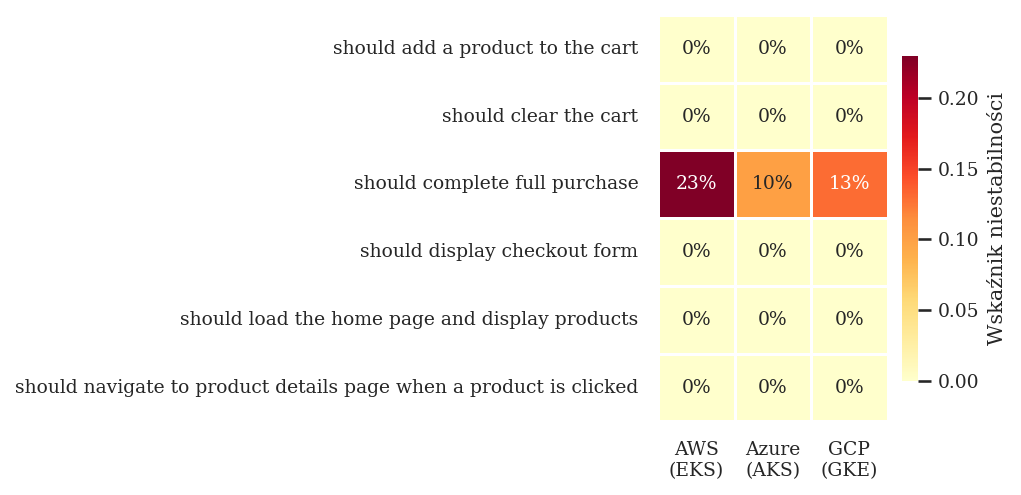

In [12]:
flakiness = []
for cloud, (env, run_dir) in CLOUDS.items():
    summary = json.loads((run_dir / 'summary.json').read_text())
    for t in summary['tests']:
        flakiness.append({'cloud': cloud, 'testName': t['testName'], 'flakyRate': t['flakyRate']})

_flk_df = pd.DataFrame(flakiness)
_flk_pivot = _flk_df.pivot(index='testName', columns='cloud', values='flakyRate')
_flk_pivot.columns = [CLOUD_LABELS[c] for c in CLOUD_ORDER]

with mpl.rc_context(LATEX_RC):
    fig, ax = plt.subplots(figsize=(6.5, 3.4))

    sns.heatmap(_flk_pivot, annot=True, fmt='.0%', cmap='YlOrRd',
                linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Wskaźnik niestabilności', 'shrink': 0.8},
                annot_kws={'size': 9})

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

    fig.tight_layout()
    fig.savefig(FIGURES / 'thesis_flakiness_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


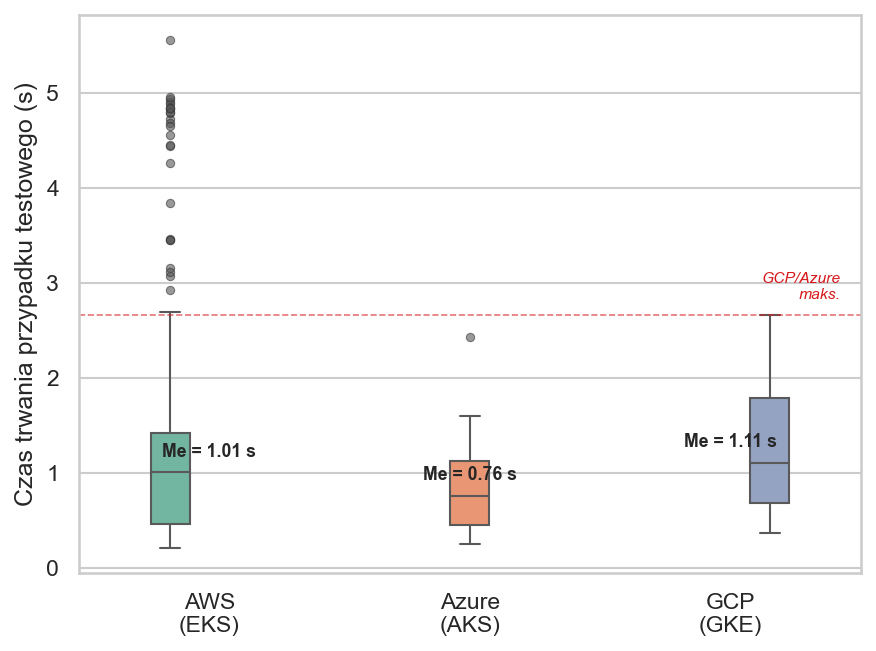

In [13]:
_order_labels = [CLOUD_LABELS[c] for c in CLOUD_ORDER]

_plot_df = df.copy()
_plot_df['testDurationS'] = _plot_df['testDuration'] / 1000
_plot_df['Cloud'] = _plot_df['cloud'].map(CLOUD_LABELS)

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.boxplot(
    data=_plot_df, x='Cloud', y='testDurationS', order=_order_labels,
    hue='Cloud', palette=[PALETTE[c] for c in CLOUD_ORDER], legend=False,
    ax=ax, width=0.7,
    flierprops=dict(marker='o', markersize=4, markerfacecolor='#555555',
                    markeredgecolor='#333333', markeredgewidth=0.5, alpha=0.6),
)

for i, cloud in enumerate(CLOUD_ORDER):
    med = _plot_df.loc[_plot_df['cloud'] == cloud, 'testDurationS'].median()
    ax.text(i, med, f'Me = {med:.2f} s',
            ha='center', va='center', fontsize=8.5, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5))

ax.axhline(y=2.66, color='#d7191c', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(2.42, 2.80, 'GCP/Azure\nmaks.', fontsize=7.5, color='#d7191c',
        va='bottom', ha='right', style='italic')

ax.set_xlabel('')
ax.set_ylabel('Czas trwania przypadku testowego (s)')

fig.tight_layout()
fig.savefig(FIGURES / 'thesis_test_case_duration_boxplot.png', dpi=300)
plt.show()


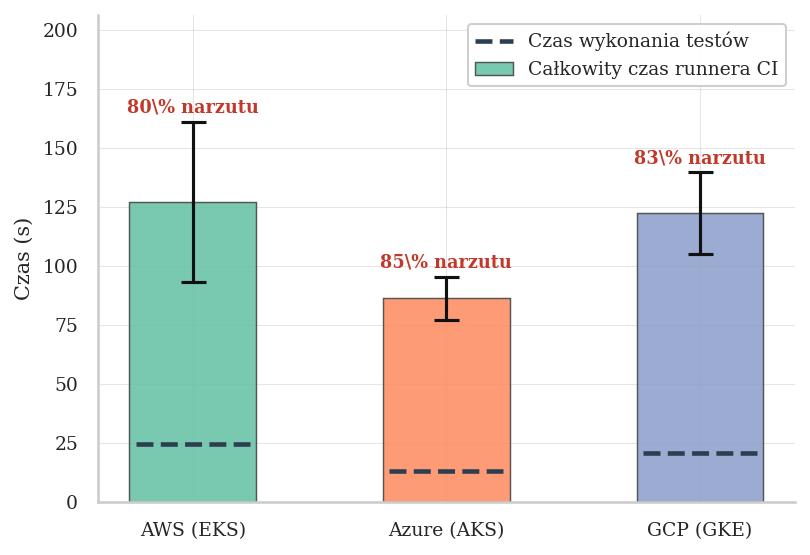


Wartości (mean ± SD):
  AWS (EKS)      total=127.3s ± 34.0s  |  tests=24.8s  |  overhead=80%
  Azure (AKS)    total=86.3s ± 9.3s  |  tests=13.1s  |  overhead=85%
  GCP (GKE)      total=122.6s ± 17.3s  |  tests=21.0s  |  overhead=83%


In [14]:
_cloud_labels_s = ['AWS (EKS)', 'Azure (AKS)', 'GCP (GKE)']
_line_color = '#2c3e50'

_runner = runner_df.copy()
_runner['totalSeconds'] = _runner['runnerQueueSeconds'] + _runner['runnerExecutionSeconds']

_total_mean = np.array([_runner[_runner['cloud'] == c]['totalSeconds'].mean() for c in CLOUD_ORDER])
_total_sd   = np.array([_runner[_runner['cloud'] == c]['totalSeconds'].std()  for c in CLOUD_ORDER])
_test_mean  = np.array([_runner[_runner['cloud'] == c]['testSeconds'].mean()  for c in CLOUD_ORDER])

_overhead_pct = (_total_mean - _test_mean) / _total_mean * 100

x = np.arange(len(CLOUD_ORDER))
w = 0.5

_rc = {**LATEX_RC,
       'legend.fontsize':  9,
       'legend.framealpha': 0.95,
       'axes.spines.top':   False,
       'axes.spines.right': False,
       'axes.grid':         True,
       'grid.linewidth':    0.5,
       'grid.alpha':        0.5,
}

with mpl.rc_context(_rc):
    fig, ax = plt.subplots(figsize=(5.5, 3.8))

    ax.bar(x, _total_mean, w, color=[PALETTE[c] for c in CLOUD_ORDER], edgecolor='#444',
           linewidth=0.7, alpha=0.88, zorder=2, label='Całkowity czas runnera CI')

    ax.errorbar(x, _total_mean, yerr=_total_sd, fmt='none',
                color='#111', capsize=6, capthick=1.5, elinewidth=1.5, zorder=4)

    for i, (xi, ts) in enumerate(zip(x, _test_mean)):
        ax.plot([xi - w * 0.45, xi + w * 0.45], [ts, ts],
                linestyle='--', color=_line_color, linewidth=2.2, zorder=5,
                solid_capstyle='butt',
                label='Czas wykonania testów' if i == 0 else '_nolegend_')

    for xi, tot, sd, pct in zip(x, _total_mean, _total_sd, _overhead_pct):
        ax.text(xi, tot + sd + 2, f'{pct:.0f}% narzutu',
                ha='center', va='bottom', fontsize=8.5,
                color='#c0392b', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(_cloud_labels_s)
    ax.set_ylabel('Czas (s)')
    ax.set_ylim(bottom=0, top=(_total_mean + _total_sd).max() * 1.28)
    ax.legend(loc='upper right')

    fig.tight_layout()
    fig.savefig(FIGURES / 'thesis_runner_overhead_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

print('\nWartości (mean ± SD):')
for c, tot, sd, ts, pct in zip(_cloud_labels_s, _total_mean, _total_sd, _test_mean, _overhead_pct):
    print(f'  {c:<14} total={tot:.1f}s ± {sd:.1f}s  |  tests={ts:.1f}s  |  overhead={pct:.0f}%')
